# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Students Productivity Dataset](https://www.kaggle.com/datasets/velvetcrystal/student-productivity-dataset/code)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Student_Productivity_Dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
9995,9996,23.0,Female,4.2,5.5,5.2,1.6,95.5,100.0,6.6,5.0,7.7,8.5,Average,No,9.0,6.3,6.51,80.59,High
9996,9997,24.0,Male,7.1,6.7,4.0,3.2,64.3,74.5,4.0,0.5,6.8,9.4,Good,Yes,7.0,7.1,6.97,62.95,Medium
9997,9998,24.0,Male,6.4,4.4,6.7,3.3,74.1,100.0,10.0,4.5,5.4,1.0,Average,No,0.0,8.2,1.80,43.79,Low
9998,9999,19.0,Male,8.1,6.8,3.5,4.1,59.5,85.9,7.2,4.6,5.0,5.8,Poor,Yes,4.1,3.5,5.24,49.48,Medium
9999,10000,18.0,Male,4.6,7.2,6.8,3.1,66.0,32.1,7.4,2.3,6.4,9.2,Good,No,7.2,4.0,5.54,62.81,Medium


## Shape of our dataset

In [5]:
df.shape

(10000, 20)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day',
       'Sleep_Hours_Per_Night', 'Screen_Time_Hours', 'Social_Media_Hours',
       'Attendance_Percentage', 'Assignments_Completed',
       'Class_Participation_Score', 'Physical_Activity_Hours_Per_Week',
       'Stress_Level', 'Motivation_Level', 'Internet_Quality', 'Part_Time_Job',
       'Extracurricular_Involvement', 'AI_Tool_Usage_Hours_Per_Week',
       'Previous_Semester_GPA', 'Productivity_Score', 'Performance_Category'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                            int64
Age                                 float64
Gender                               object
Study_Hours_Per_Day                 float64
Sleep_Hours_Per_Night               float64
Screen_Time_Hours                   float64
Social_Media_Hours                  float64
Attendance_Percentage               float64
Assignments_Completed               float64
Class_Participation_Score           float64
Physical_Activity_Hours_Per_Week    float64
Stress_Level                        float64
Motivation_Level                    float64
Internet_Quality                     object
Part_Time_Job                        object
Extracurricular_Involvement         float64
AI_Tool_Usage_Hours_Per_Week        float64
Previous_Semester_GPA               float64
Productivity_Score                  float64
Performance_Category                 object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

## Get numerical columns

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

## Remove ID column

In [10]:
num_cols = num_cols.drop('Student_ID')

## Fill numerical null values with median

In [11]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

## Get categorical columns

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns

## Fill categorical null values with mode

In [13]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Check Null Value

In [14]:
df.isnull().sum()

Student_ID                          0
Age                                 0
Gender                              0
Study_Hours_Per_Day                 0
Sleep_Hours_Per_Night               0
Screen_Time_Hours                   0
Social_Media_Hours                  0
Attendance_Percentage               0
Assignments_Completed               0
Class_Participation_Score           0
Physical_Activity_Hours_Per_Week    0
Stress_Level                        0
Motivation_Level                    0
Internet_Quality                    0
Part_Time_Job                       0
Extracurricular_Involvement         0
AI_Tool_Usage_Hours_Per_Week        0
Previous_Semester_GPA               0
Productivity_Score                  0
Performance_Category                0
dtype: int64

## Check Dupicate Value

In [15]:
df.duplicated().sum()

np.int64(0)

## Summary

In [16]:
df.describe()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,20.13280,4.219260,6.976850,6.047230,3.031850,79.821970,74.259520,5.991380,3.194000,5.543720,5.958660,4.049310,5.532900,6.489918,54.607333
std,2886.89568,2.47814,1.934479,1.296688,2.407983,1.722842,12.272877,16.490008,2.130312,2.237724,2.091318,2.093426,2.346785,3.866649,1.567687,12.340640
min,1.00000,16.00000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.00000,2.900000,6.100000,4.400000,1.800000,71.400000,63.100000,4.600000,1.600000,4.100000,4.500000,2.300000,2.700000,5.440000,46.640000
50%,5000.50000,20.00000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,7500.25000,22.00000,5.500000,7.900000,7.700000,4.200000,89.000000,86.600000,7.500000,4.300000,7.000000,7.400000,5.700000,7.400000,7.580000,63.032500
max,10000.00000,25.00000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


# EDA

In [17]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

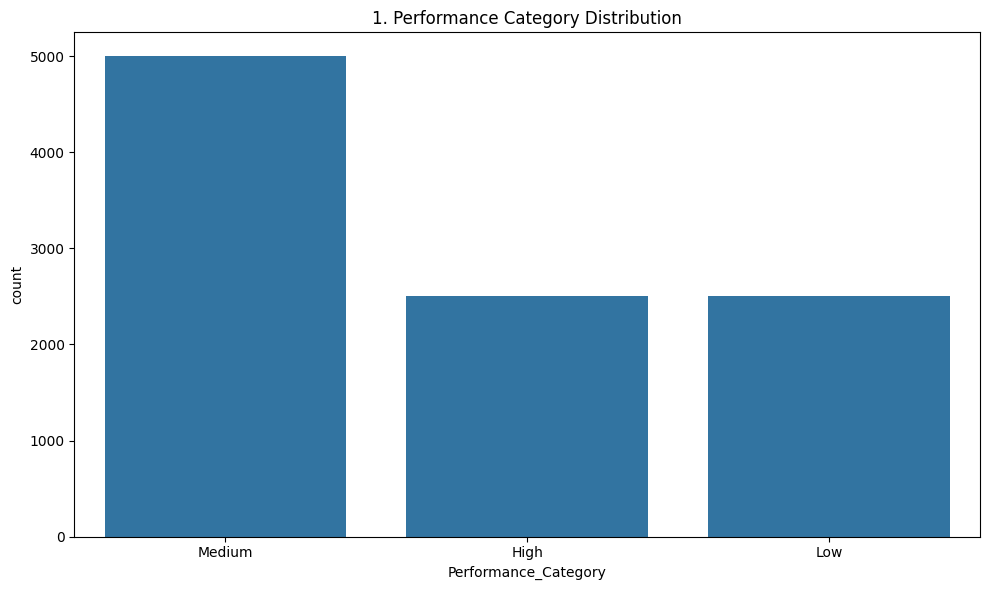

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Performance_Category')
plt.title(f'{plot_no}. Performance Category Distribution')
show_fig()
plot_no += 1

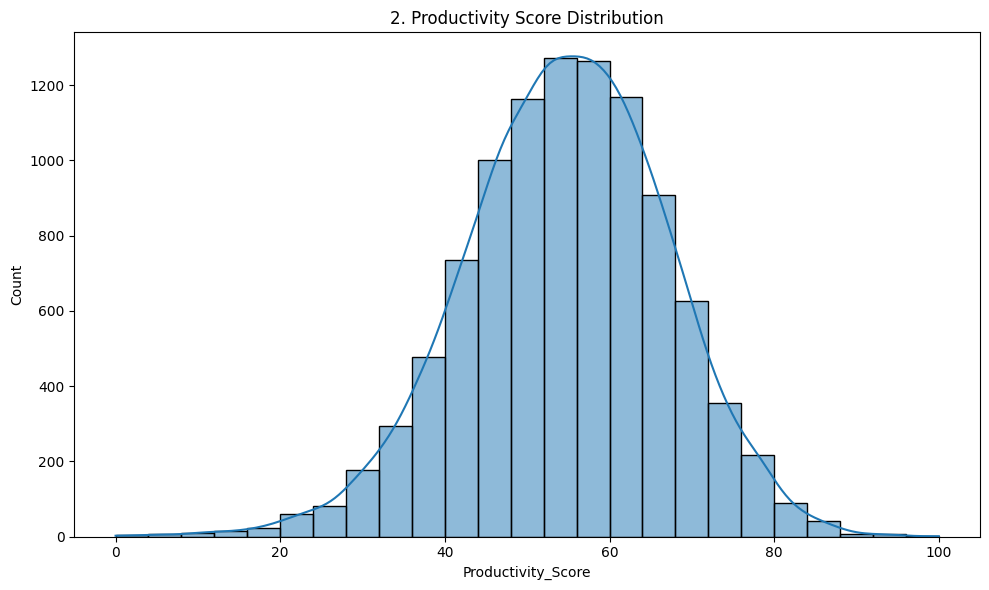

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Productivity_Score', kde=True, bins=25)
plt.title(f'{plot_no}. Productivity Score Distribution')
show_fig()
plot_no += 1

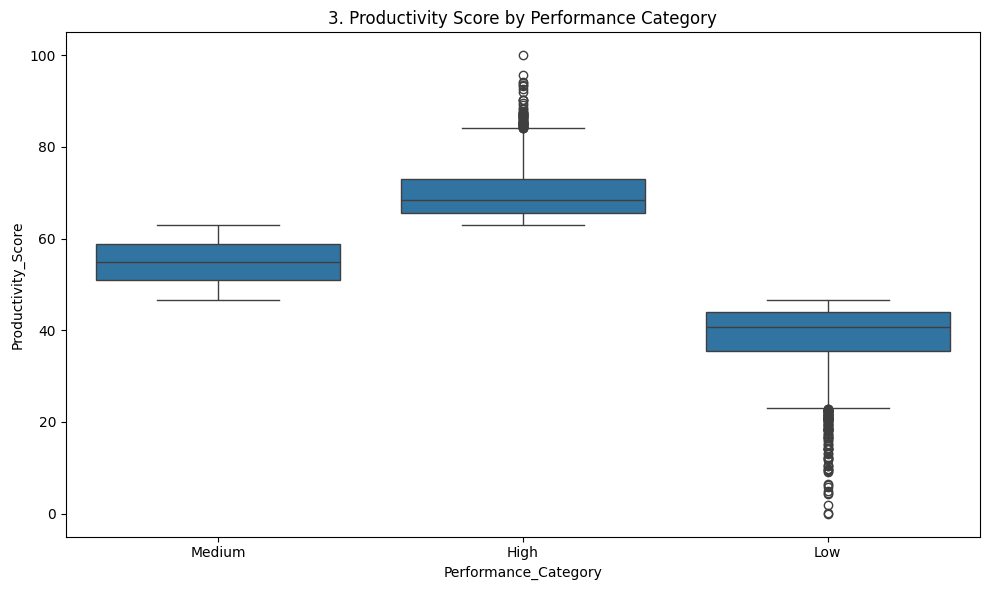

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Performance_Category', y='Productivity_Score')
plt.title(f'{plot_no}. Productivity Score by Performance Category')
show_fig()
plot_no += 1

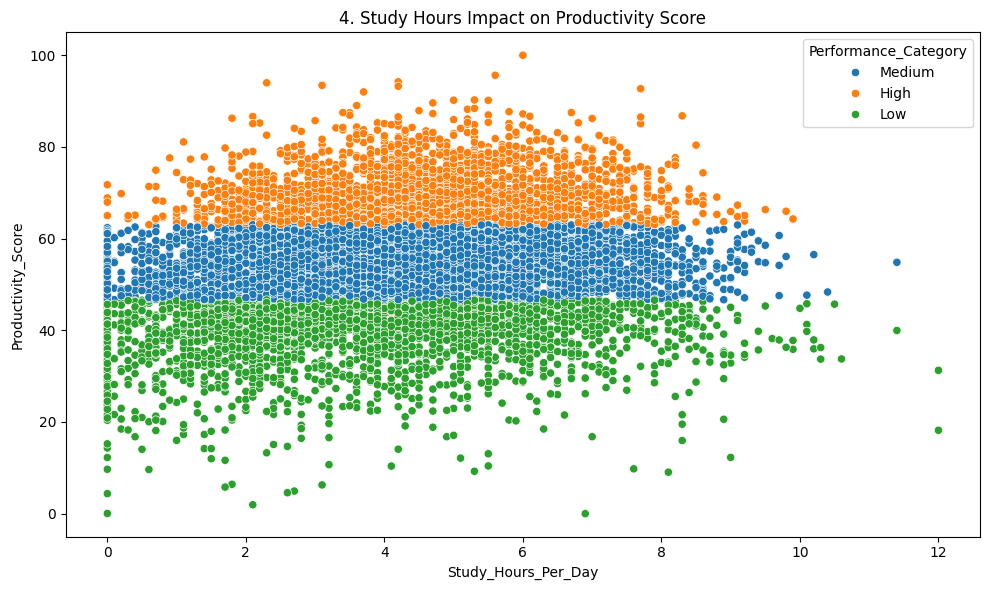

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Study_Hours_Per_Day', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Study Hours Impact on Productivity Score')
show_fig()
plot_no += 1

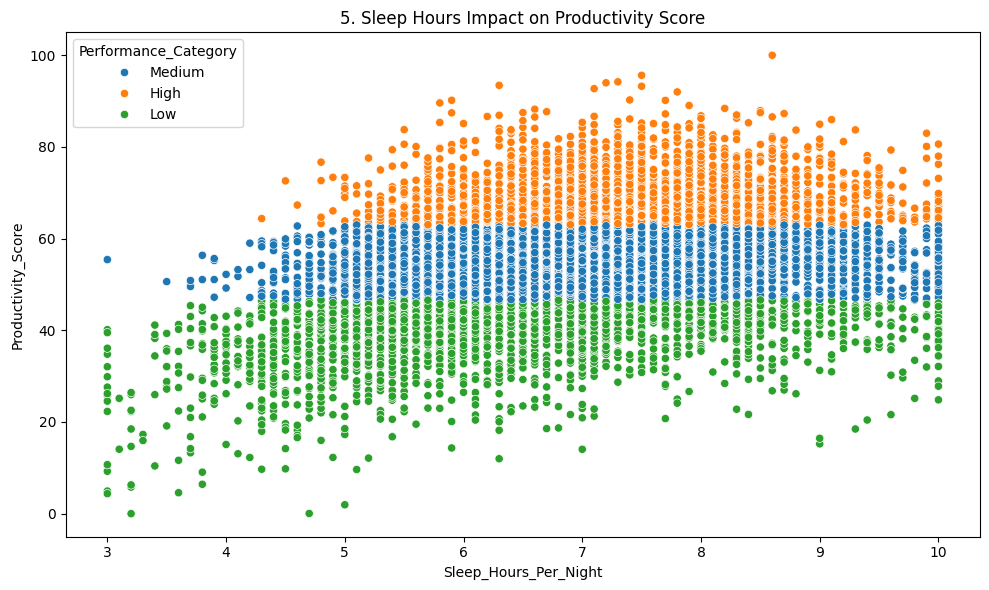

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Sleep Hours Impact on Productivity Score')
show_fig()
plot_no += 1

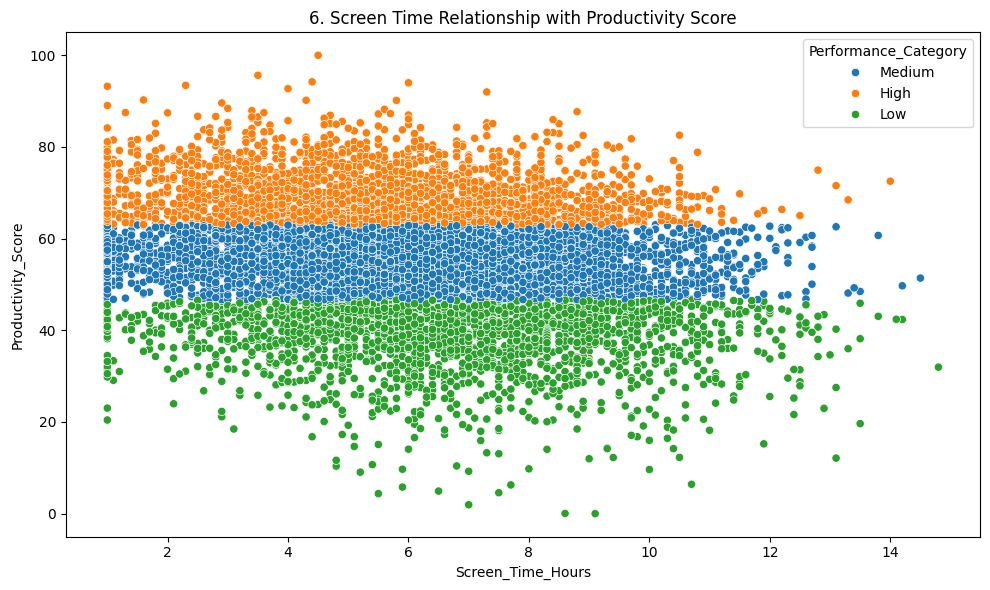

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Screen_Time_Hours', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Screen Time Relationship with Productivity Score')
show_fig()
plot_no += 1

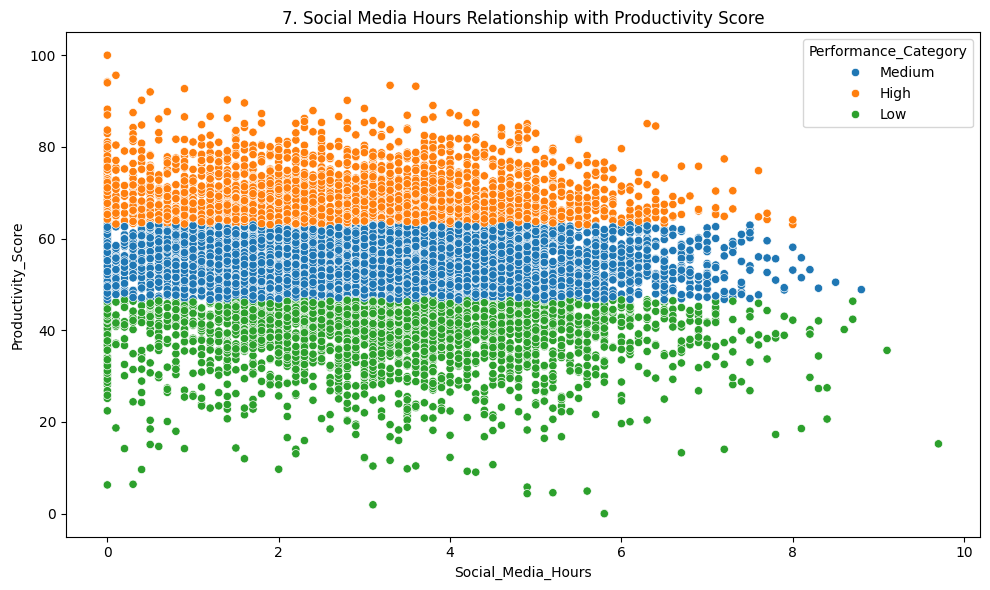

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Social_Media_Hours', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Social Media Hours Relationship with Productivity Score')
show_fig()
plot_no += 1

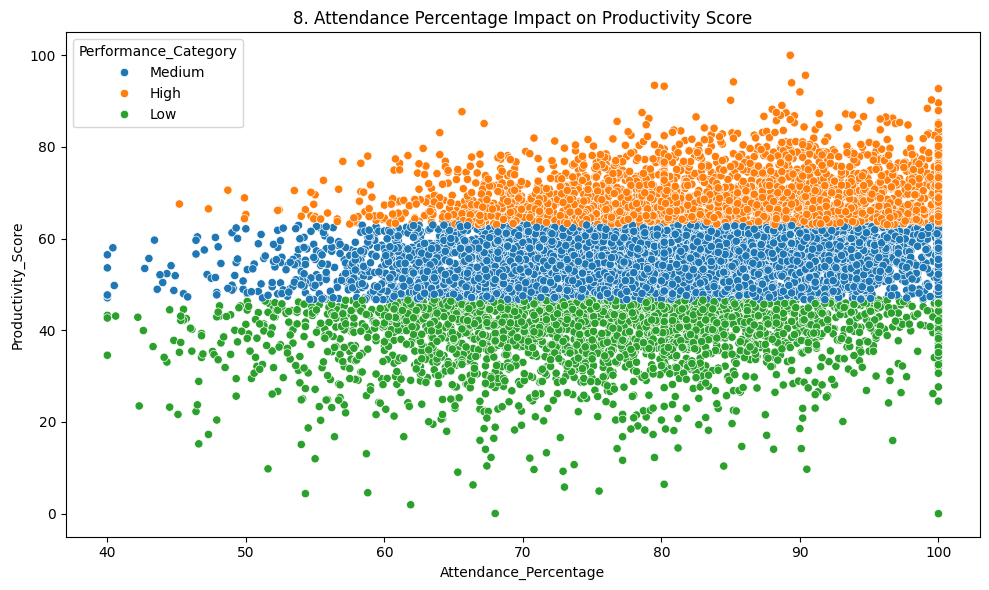

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attendance_Percentage', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Attendance Percentage Impact on Productivity Score')
show_fig()
plot_no += 1

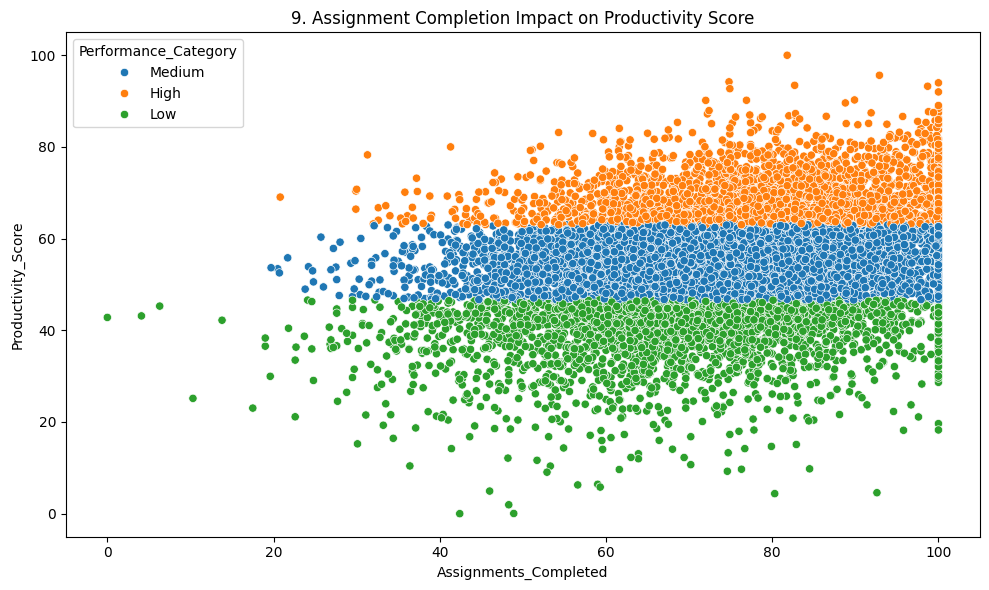

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Assignments_Completed', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Assignment Completion Impact on Productivity Score')
show_fig()
plot_no += 1

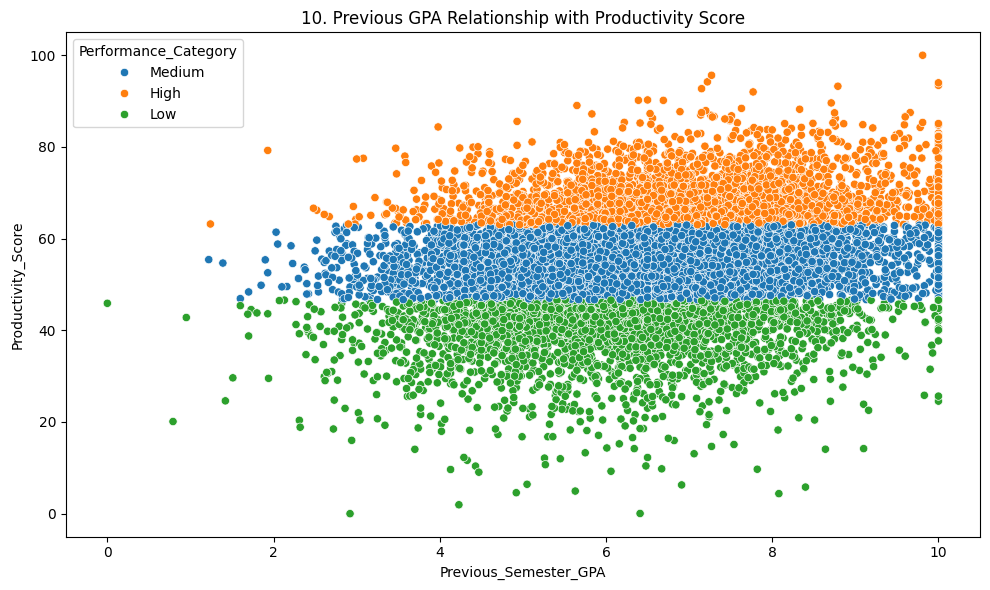

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Previous_Semester_GPA', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Previous GPA Relationship with Productivity Score')
show_fig()
plot_no += 1

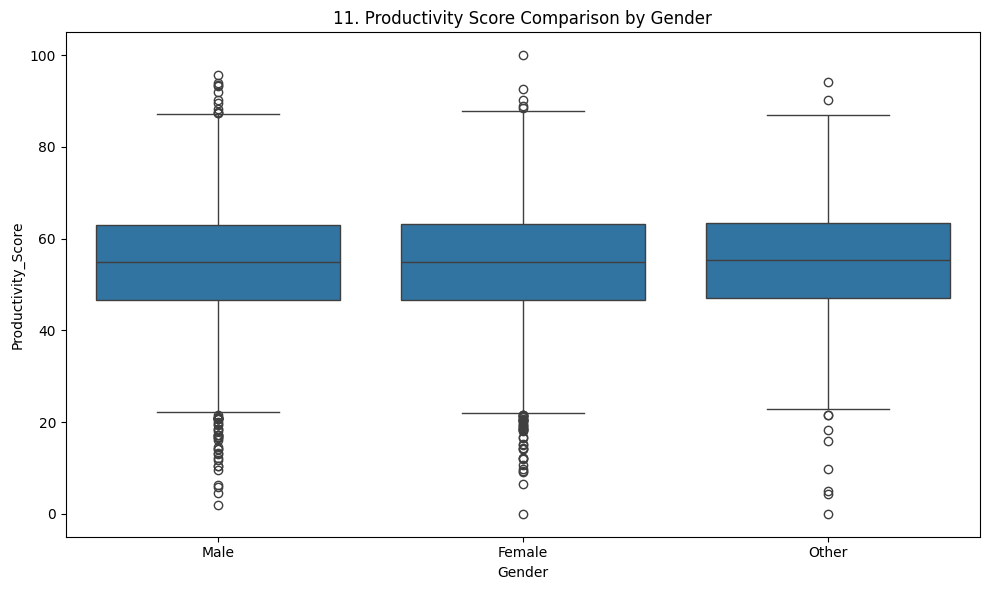

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Productivity_Score')
plt.title(f'{plot_no}. Productivity Score Comparison by Gender')
show_fig()
plot_no += 1

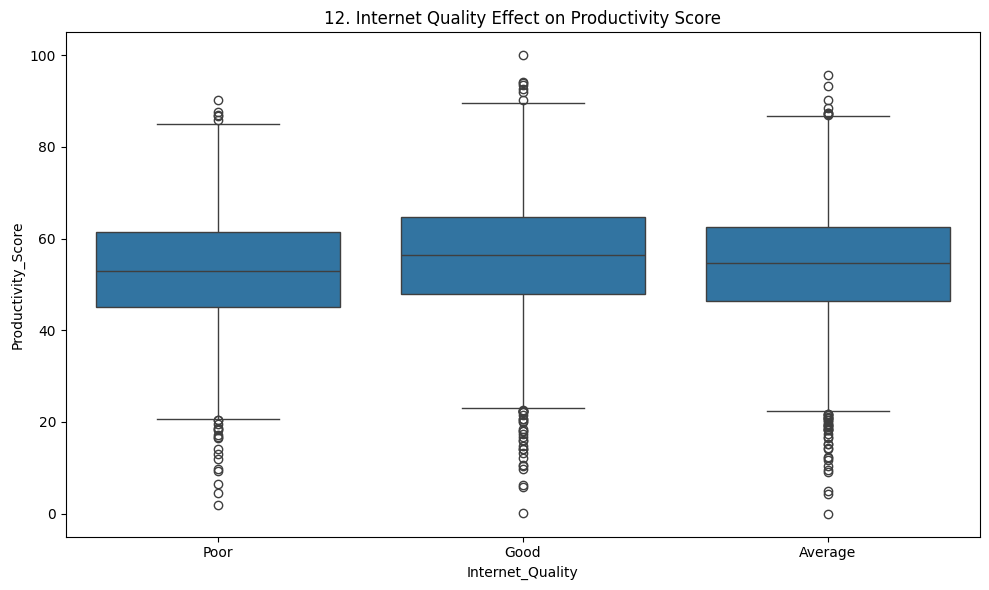

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Internet_Quality', y='Productivity_Score')
plt.title(f'{plot_no}. Internet Quality Effect on Productivity Score')
show_fig()
plot_no += 1

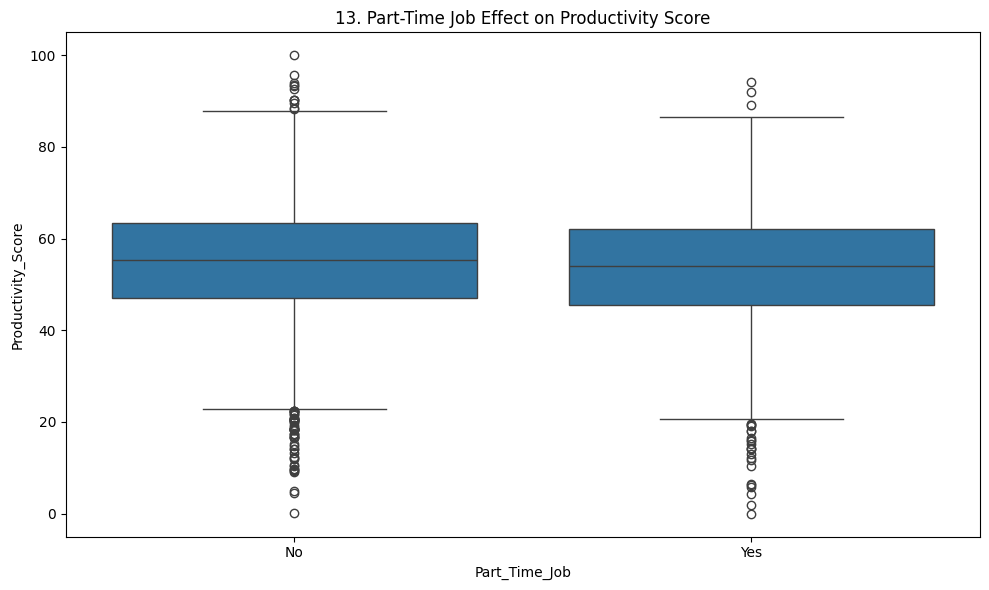

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Part_Time_Job', y='Productivity_Score')
plt.title(f'{plot_no}. Part-Time Job Effect on Productivity Score')
show_fig()
plot_no += 1

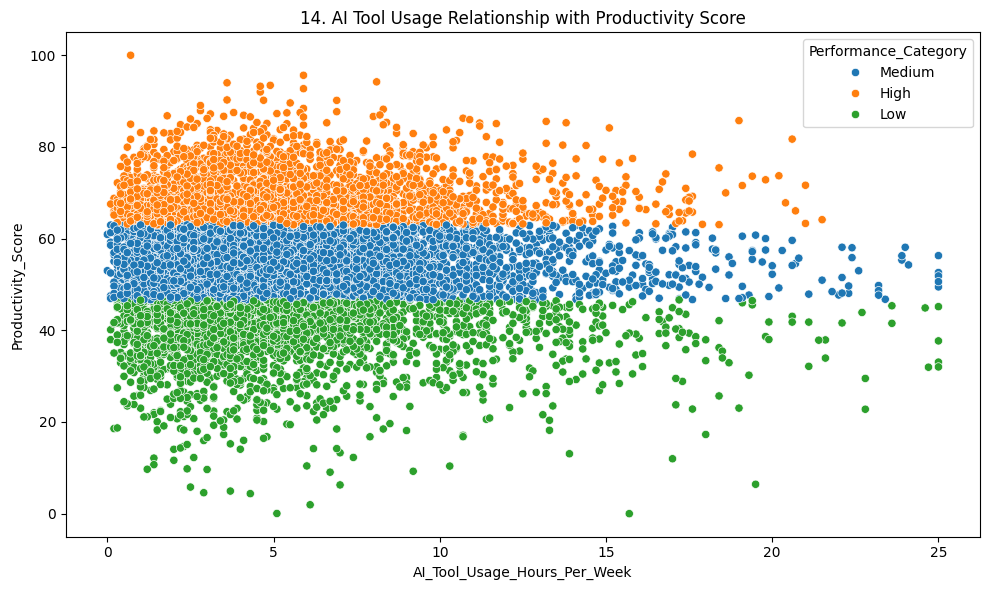

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AI_Tool_Usage_Hours_Per_Week', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. AI Tool Usage Relationship with Productivity Score')
show_fig()
plot_no += 1

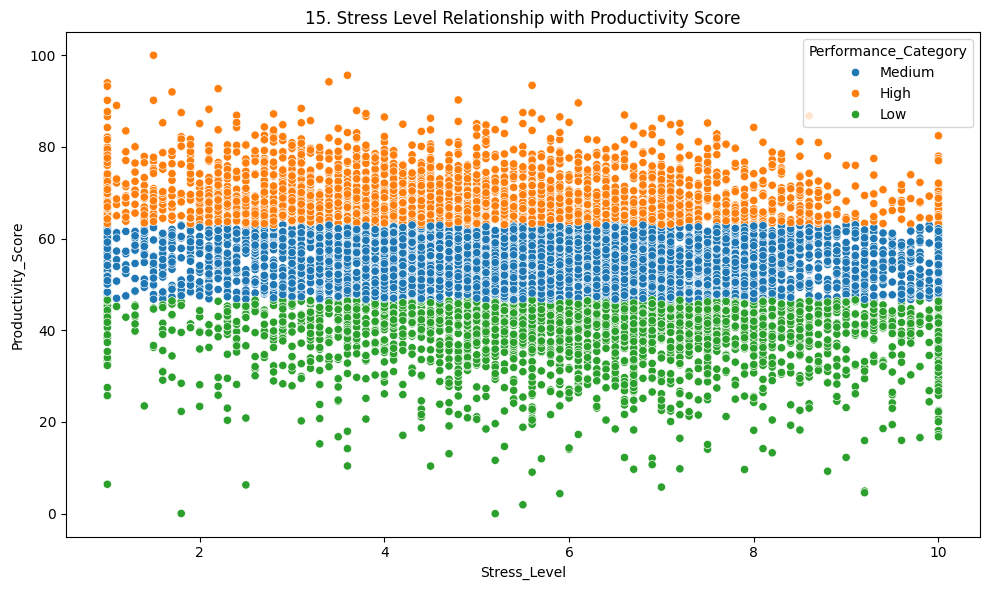

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Stress_Level', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Stress Level Relationship with Productivity Score')
show_fig()
plot_no += 1

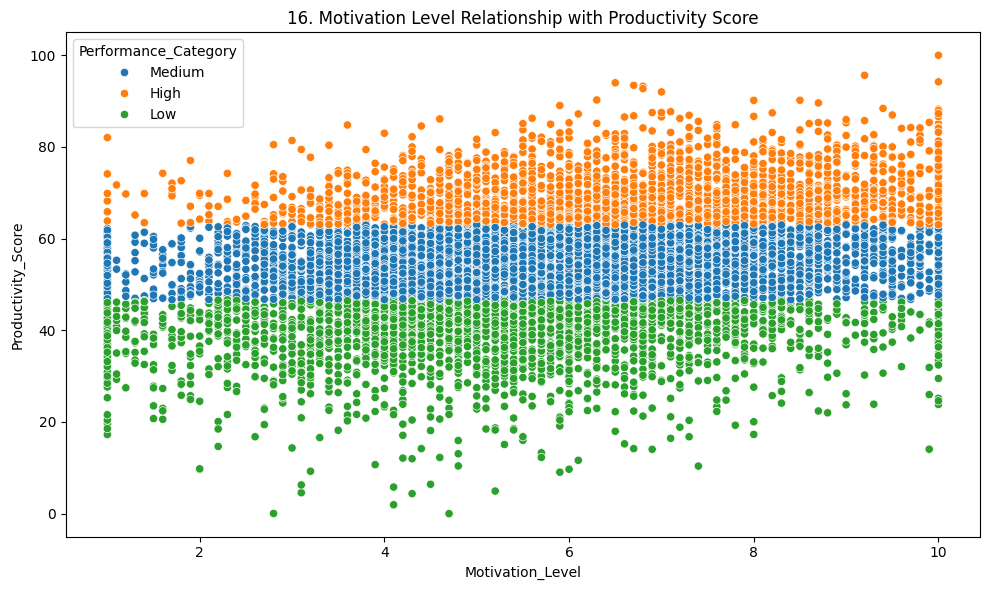

In [33]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Motivation_Level', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Motivation Level Relationship with Productivity Score')
show_fig()
plot_no += 1

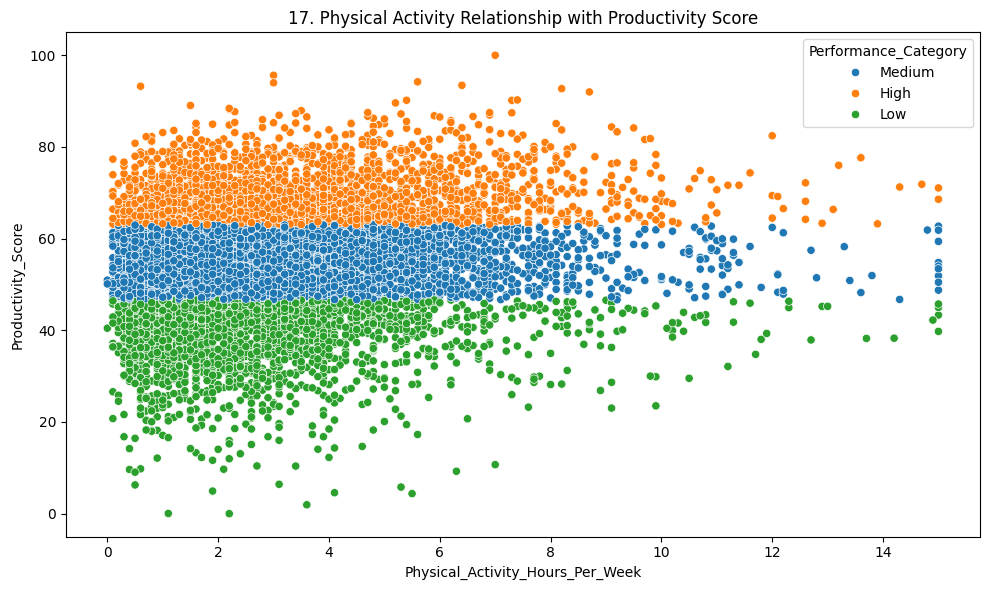

In [34]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Physical_Activity_Hours_Per_Week', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Physical Activity Relationship with Productivity Score')
show_fig()
plot_no += 1

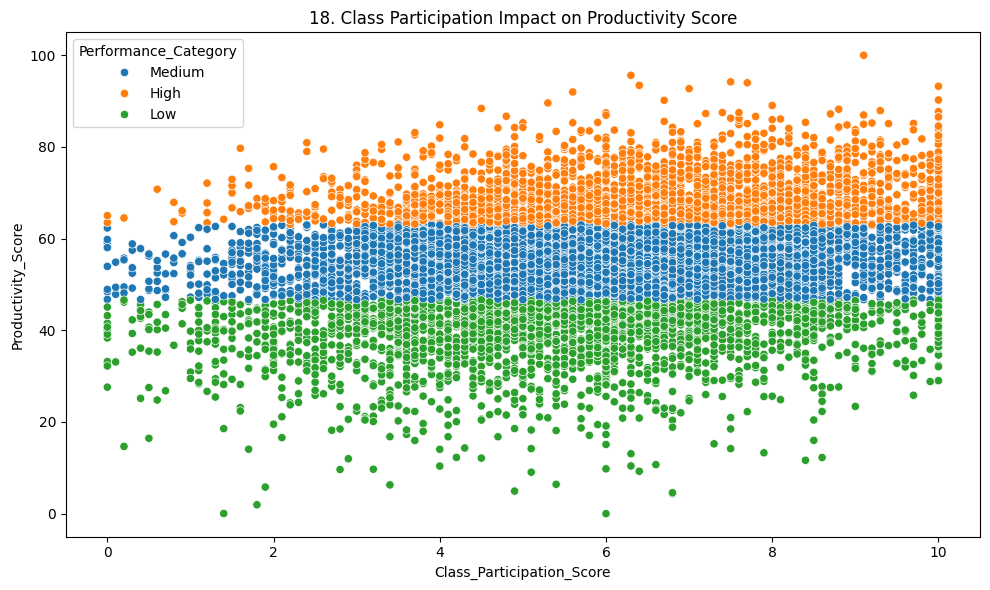

In [35]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Class_Participation_Score', y='Productivity_Score', hue='Performance_Category')
plt.title(f'{plot_no}. Class Participation Impact on Productivity Score')
show_fig()
plot_no += 1

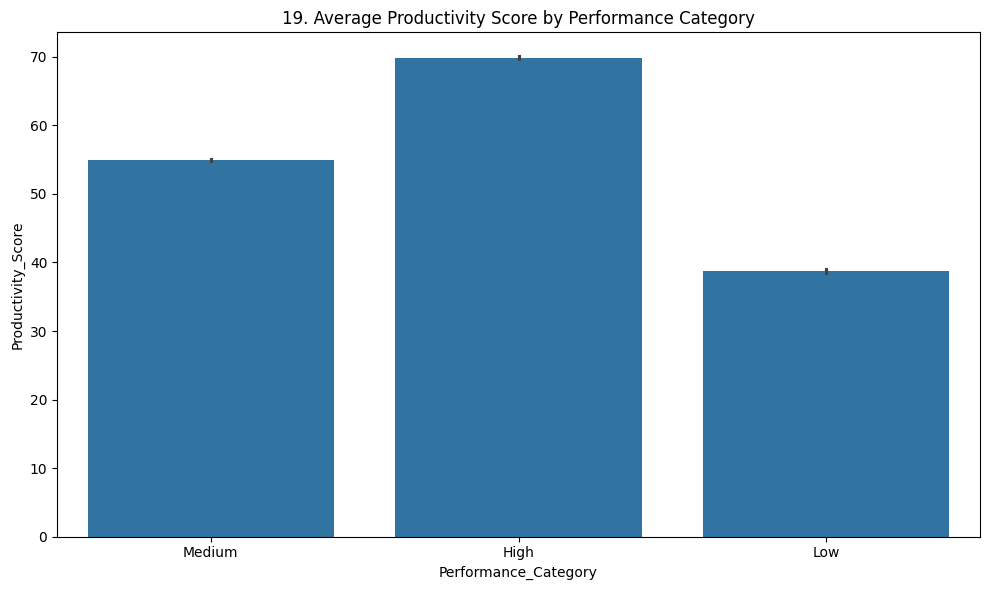

In [36]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Performance_Category', y='Productivity_Score', estimator='mean')
plt.title(f'{plot_no}. Average Productivity Score by Performance Category')
show_fig()
plot_no += 1

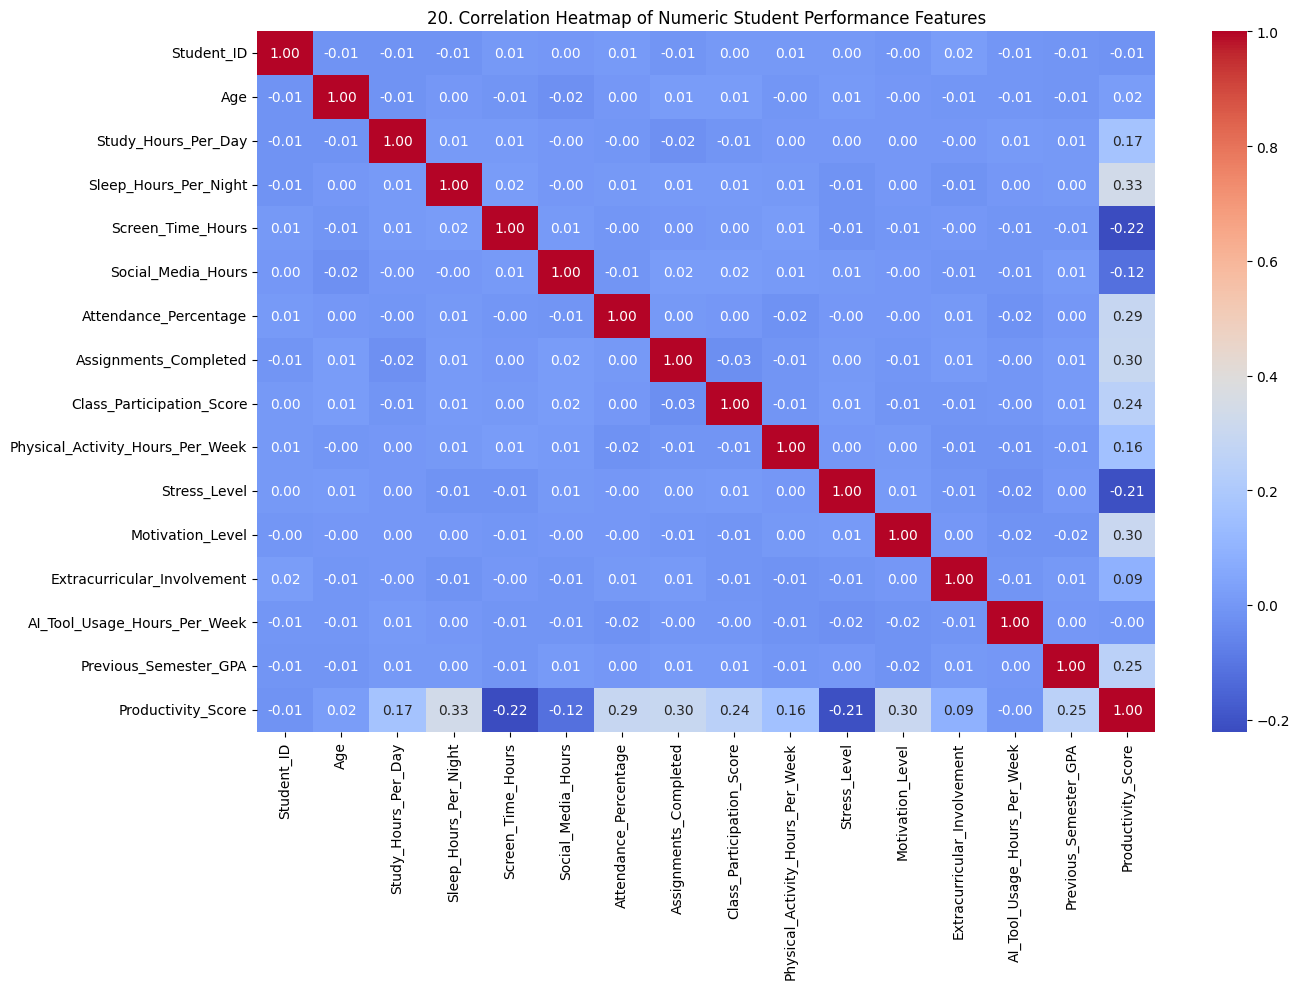

In [37]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Student Performance Features')
show_fig()
plot_no += 1

# Model Training

## copy dataframe

In [38]:
data = df.copy()

## remove ID column

In [39]:
data = data.drop(columns=['Student_ID'], errors='ignore')

## encode categorical columns

In [40]:
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

## select features and target

In [41]:
X = data.drop('Performance_Category', axis=1)
y = data['Performance_Category']

## split data into train and test

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## scale feature values

In [43]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## create supervised classification model

In [44]:
model = LogisticRegression(max_iter=1000)

## train model

In [45]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## predict test data

In [46]:
y_pred = model.predict(X_test)

## calculate accuracy

In [47]:
accuracy = accuracy_score(y_test, y_pred)

## print accuracy score

In [48]:
print("Accuracy Score:", accuracy)

Accuracy Score: 0.9905


## print classification report

In [49]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       500
           1       0.99      0.99      0.99       500
           2       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



## create confusion matrix

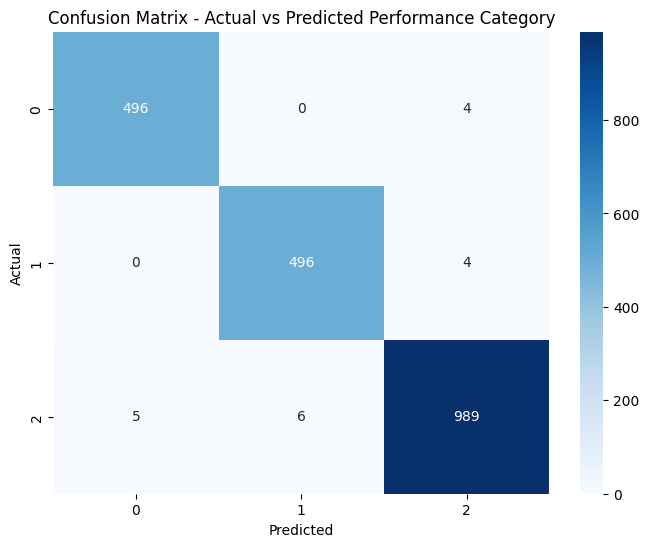

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Actual vs Predicted Performance Category")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()